In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from keras.utils.np_utils import to_categorical
from sklearn.utils import class_weight
import warnings

import keras
from keras.models import Sequential
from keras.models import Model
from keras.layers import Reshape
from keras.layers import Dense, Activation, Flatten, Convolution1D, Dropout,MaxPooling1D
from tensorflow.keras.optimizers import Adam 
from keras.callbacks import LearningRateScheduler

import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error

from tensorflow.keras.layers import BatchNormalization
import cv2
from tensorflow.keras.optimizers import Adam , Adadelta

warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
train = pd.read_csv("../input/mitbih/MIt-BIH Datasets/train.csv" , header = None)
validate = pd.read_csv("../input/mitbih/MIt-BIH Datasets/validate.csv", header = None)
test = pd.read_csv("../input/mitbih/MIt-BIH Datasets/test.csv" , header = None)
display_test = pd.read_csv("../input/display-test/test.csv" , header = None)

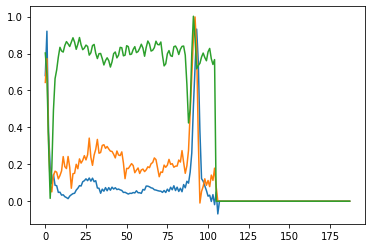

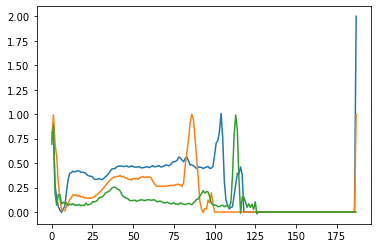

In [3]:
for i in range(3): plt.plot(train.iloc[i])
plt.show()
for i in range(3): plt.plot(test.iloc[i])
plt.show()

In [4]:
train.rename(columns={187:"Class"}, inplace=True)
test.rename(columns={187:"Class"}, inplace=True)
validate.rename(columns={187:"Class"}, inplace=True)
display_test.rename(columns={187:"Class"}, inplace=True)

In [5]:
train['Class'].unique()

array([ 0., 15.,  8., 17.,  2.,  1.,  4., 12.,  5., 14., 10.,  6., 18.])

In [6]:
test['Class'].unique()

array([ 2.,  1.,  0.,  8., 15.,  4., 10.,  5., 12., 17.,  6., 14., 18.])

In [7]:
mapping = {    
               0 : 'Normal Beat',
               1 : 'Left bundle branch block beat',
               2 : 'Right bundle branch block beat',
               4 : 'Atrial premature beat',
               5 : 'Aberrated atrial premature beat',
               6 : 'Nodal (junctional) premature beat',
             
               8 : 'Premature ventricular contraction',
               10 : 'Fusion of ventricular and normal beat',
               
               12 : 'Nodal (junctional) escape beat',
               14 : 'Ventricular escape beat',
               15 : 'Paced beat',
             
               17 : 'Unclassifiable beat',
                18 : 'Fusion of ventricular and normal beat'

               }

In [8]:
train['label'] = train.iloc[:, -1].map(mapping)
test['label'] = test.iloc[:, -1].map(mapping)
validate['label'] = validate.iloc[:, -1].map(mapping)
display_test['label'] = display_test.iloc[:, -1].map(mapping)



In [9]:
# Applying Smote
df_15=train[train['Class']==15]
df_2=train[train['Class']==2]
df_1=train[train['Class']==1]
df_8=train[train['Class']==8]
df_4=train[train['Class']==4]
df_10=train[train['Class']==10]
df_12=train[train['Class']==12]
df_6=train[train['Class']==6]
df_14=train[train['Class']==14]
df_5=train[train['Class']==5]
df_17=train[train['Class']==17]
df_18= train[train['Class']==18]


df_0=(train[train['Class']==0]).sample(n=20000,random_state=42)


train=pd.concat([df_0,df_15,df_2,df_1,df_8,df_4,df_10,df_12,df_6,df_14,df_5,df_17,df_18])

In [10]:
X_train=train.iloc[:,:186].values
X_test=test.iloc[:,:186].values
X_validate = validate.iloc[: , :186].values
X_display = display_test.iloc[: , :186].values

In [11]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=1)
X_train, y_train = oversample.fit_resample(X_train, train["Class"])


In [12]:
from collections import Counter

counter = Counter(y_train)
print(counter)

Counter({0.0: 20000, 15.0: 20000, 2.0: 20000, 1.0: 20000, 8.0: 20000, 4.0: 20000, 10.0: 20000, 12.0: 20000, 6.0: 20000, 14.0: 20000, 5.0: 20000, 17.0: 20000, 18.0: 20000})


In [13]:
X_train = X_train.reshape(len(X_train), X_train.shape[1],1)
X_test = X_test.reshape(len(X_test), X_test.shape[1],1)
X_validate = X_validate.reshape(len(X_validate), X_validate.shape[1],1)
X_display = X_display.reshape(len(X_display), X_display.shape[1],1)

In [14]:
target_test=test["Class"]
target_validate=validate["Class"]
target_display = display_test["Class"]

In [15]:
y_train= np.array(y_train).reshape(-1,1)
y_test= np.array(target_test).reshape(-1,1)
y_validate= np.array(target_validate).reshape(-1,1)
y_display = np.array(target_display).reshape(-1,1)

In [16]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
encoder_df1 = pd.DataFrame(enc.fit_transform(y_train).toarray())
encoder_df2 = pd.DataFrame(enc.fit_transform(y_test).toarray())
encoder_df3 = pd.DataFrame(enc.fit_transform(y_validate).toarray())
encoder_df4 = pd.DataFrame(enc.fit_transform(y_display).toarray())




In [17]:
y_train = np.array(encoder_df1)
y_test = np.array(encoder_df2)
y_validate = np.array(encoder_df3)
y_display = np.array(encoder_df4)

In [18]:
import tensorflow
X_train =tensorflow.convert_to_tensor(X_train, dtype=tensorflow.float32)
y_train = tensorflow.convert_to_tensor(y_train, dtype=tensorflow.float32)

X_test = tensorflow.convert_to_tensor(X_test, dtype=tensorflow.float32)
y_test = tensorflow.convert_to_tensor(y_test, dtype=tensorflow.float32)

X_validate = tensorflow.convert_to_tensor(X_validate, dtype=tensorflow.float32)
y_validate = tensorflow.convert_to_tensor(y_validate, dtype=tensorflow.float32)

X_display = tensorflow.convert_to_tensor(X_display, dtype=tensorflow.float32)
y_display = tensorflow.convert_to_tensor(y_display, dtype=tensorflow.float32)


2022-05-19 21:45:19.370447: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:45:19.495400: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:45:19.496296: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:45:19.499687: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [19]:
X_train.shape

TensorShape([260000, 186, 1])

In [20]:
n_obs, feature, depth = X_train.shape
batch_size = 500

In [21]:

# model Residual

from keras.layers import Input, Dense, Conv1D, MaxPooling1D, Softmax, Add, Flatten, Activation# , Dropout

inp = Input(shape=(feature, depth))
C = Conv1D(filters=32, kernel_size=5, strides=1)(inp)
C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
A11 = Activation("relu")(C11)

C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
S11 = Add()([C12, C])
A12 = Activation("relu")(S11)
M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
A21 = Activation("relu")(C21)
C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
S21 = Add()([C22, M11])
A22 = Activation("relu")(S11)
M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
A31 = Activation("relu")(C31)
C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
S31 = Add()([C32, M21])
A32 = Activation("relu")(S31)
M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
A41 = Activation("relu")(C41)
C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
S41 = Add()([C42, M31])
A42 = Activation("relu")(S41)
M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
A51 = Activation("relu")(C51)
C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
S51 = Add()([C52, M41])
A52 = Activation("relu")(S51)
M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

F1 = Flatten()(M51)

D1 = Dense(32)(F1)
A6 = Activation("relu")(D1)
D2 = Dense(32)(A6)
D3 = Dense(13)(D2)
A7 = Softmax()(D3)

model = Model(inputs=inp, outputs=A7)

In [22]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 186, 1)]     0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 182, 32)      192         input_1[0][0]                    
__________________________________________________________________________________________________
conv1d_1 (Conv1D)               (None, 182, 32)      5152        conv1d[0][0]                     
__________________________________________________________________________________________________
activation (Activation)         (None, 182, 32)      0           conv1d_1[0][0]                   
______________________________________________________________________________________________

In [23]:
adam = Adam(lr = 0.001, beta_1 = 0.9, beta_2 = 0.999)

In [24]:
def exp_decay(epoch):
    initial_lrate = 0.001
    k = 0.75
    t = n_obs//(10000 * batch_size)  # every epoch we do n_obs/batch_size iteration
    lrate = initial_lrate * np.math.exp(-k*t)
    return lrate

In [25]:
lrate = LearningRateScheduler(exp_decay)

In [26]:
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
my_callbacks = [
#    keras.callbacks.EarlyStopping(monitor='val_loss' , patience=8),
    keras.callbacks.ModelCheckpoint(filepath='Residual.h5' , monitor = 'val_loss' , save_best_only=True),
    lrate
]

In [28]:
history=model.fit(X_train, y_train,epochs=75,callbacks=my_callbacks, batch_size=500,validation_data=(X_validate,y_validate))

2022-05-19 21:45:24.319972: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/75


2022-05-19 21:45:26.229595: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


520/520 [==============================] - 16s 15ms/step - loss: 0.5242 - accuracy: 0.8277 - val_loss: 0.5849 - val_accuracy: 0.8123
Epoch 2/75
520/520 [==============================] - 7s 14ms/step - loss: 0.1136 - accuracy: 0.9655 - val_loss: 0.2505 - val_accuracy: 0.9216
Epoch 3/75
520/520 [==============================] - 7s 14ms/step - loss: 0.0746 - accuracy: 0.9770 - val_loss: 0.2075 - val_accuracy: 0.9381
Epoch 4/75
520/520 [==============================] - 8s 15ms/step - loss: 0.0568 - accuracy: 0.9819 - val_loss: 0.1467 - val_accuracy: 0.9600
Epoch 5/75
520/520 [==============================] - 8s 15ms/step - loss: 0.0442 - accuracy: 0.9859 - val_loss: 0.1767 - val_accuracy: 0.9487
Epoch 6/75
520/520 [==============================] - 8s 14ms/step - loss: 0.0370 - accuracy: 0.9883 - val_loss: 0.1156 - val_accuracy: 0.9708
Epoch 7/75
520/520 [==============================] - 7s 14ms/step - loss: 0.0337 - accuracy: 0.9891 - val_loss: 0.1371 - val_accuracy: 0.9635
Epoch 8/7

In [29]:
y_pred = model.predict(X_test, batch_size=1000)

In [30]:
y_pred=np.argmax(y_pred, axis=1)

In [31]:
yyy_test = np.argmax(y_test , axis = 1)

In [32]:
print("Model Accuracy is : " , accuracy_score(yyy_test, y_pred) )

Model Accuracy is :  0.9797756571237234


In [33]:
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=128)
print("test loss, test acc:", results)


Evaluate on test data
234/234 [==============================] - 1s 3ms/step - loss: 0.1215 - accuracy: 0.9798
test loss, test acc: [0.12150793522596359, 0.9797756671905518]


Text(0, 0.5, 'Loss')

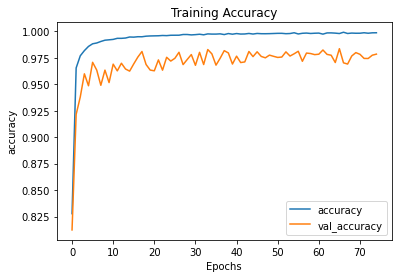

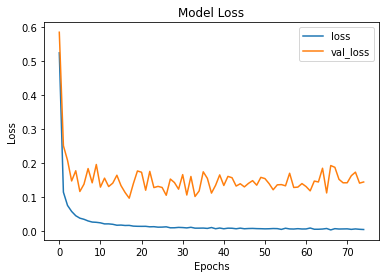

In [34]:
# converting hsitory to dataframe
pd.DataFrame(history.history)

pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')

pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [35]:
print(classification_report(yyy_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22457
           1       0.99      0.99      0.99      1274
           2       1.00      0.99      0.99      1986
           3       0.77      0.94      0.84       618
           4       0.58      0.68      0.62        22
           5       0.72      0.95      0.82        22
           6       0.90      0.96      0.93       982
           7       0.56      0.85      0.67       169
           8       0.77      0.89      0.83        54
           9       0.96      1.00      0.98        26
          10       1.00      0.99      0.99      1932
          11       0.89      0.94      0.92       320
          12       0.00      0.00      0.00         3

    accuracy                           0.98     29865
   macro avg       0.78      0.86      0.81     29865
weighted avg       0.98      0.98      0.98     29865



In [36]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



Confusion matrix, without normalization


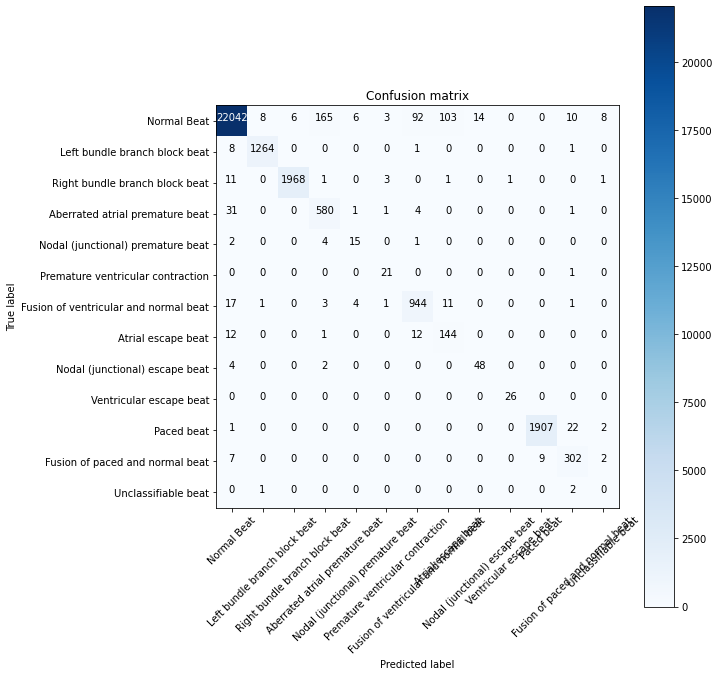

In [37]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(yyy_test, y_pred)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=[
                                           
                'Normal Beat',
                'Left bundle branch block beat',
                'Right bundle branch block beat',
               # 'Atrial premature beat',
                'Aberrated atrial premature beat',
                'Nodal (junctional) premature beat',
                #'Supraventricular premature beat',
                'Premature ventricular contraction',
                'Fusion of ventricular and normal beat',
                'Atrial escape beat',
                'Nodal (junctional) escape beat',
                'Ventricular escape beat',
                'Paced beat',
                'Fusion of paced and normal beat',
                'Unclassifiable beat'

],
                      title='Confusion matrix')
plt.show()

In [38]:
from sklearn import metrics
import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, label_ranking_average_precision_score, label_ranking_loss, coverage_error 


In [39]:
fpr, tpr, thresholds = metrics.roc_curve(yyy_test, y_pred, pos_label=2)

In [40]:
print(fpr)

[0.00000000e+00 4.30431508e-04 1.26259909e-02 8.13515549e-02
 8.22841565e-02 8.45080527e-02 9.37623301e-02 1.31568564e-01
 1.32501166e-01 1.33433767e-01 1.60515083e-01 1.60730299e-01
 2.06427777e-01 1.00000000e+00]


In [41]:
print(tpr)

[0.00000000e+00 5.03524673e-04 5.03524673e-04 5.03524673e-04
 1.00704935e-03 1.00704935e-03 1.51057402e-03 1.51057402e-03
 3.02114804e-03 3.02114804e-03 3.52467271e-03 9.94461229e-01
 9.94461229e-01 1.00000000e+00]


In [42]:
print(thresholds)

[13 12 11 10  9  8  7  6  5  4  3  2  1  0]


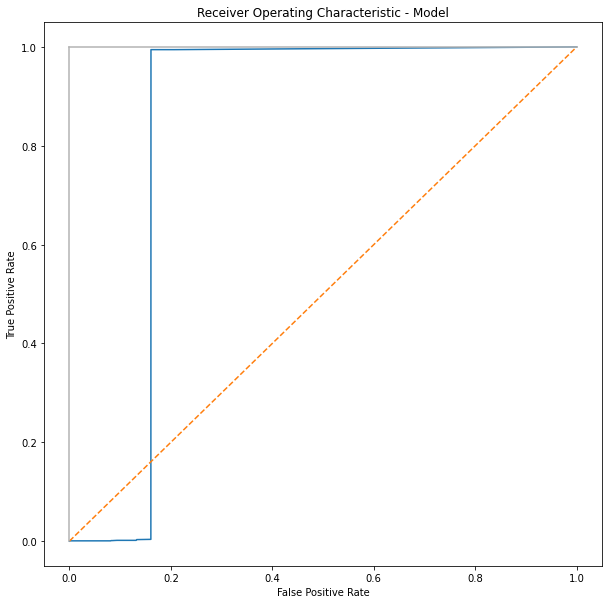

In [43]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Model')
plt.plot(fpr, tpr)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [44]:

auc = metrics.auc(fpr, tpr)
print("Auc is : ")
print(auc )


Auc is : 
0.8371323989039529


In [45]:
import tensorflow.keras.backend as K
import tensorflow as tf
tf.compat.v1.disable_eager_execution()
#tf.compat.v1.reset_default_graph()


run_eagerly = True



def gradcam(model, x, index, layer_name):
    # 取得影像的分類類別
    #with tf.Graph().as_default():
    model = tf.keras.models.load_model('Residual.h5')
    preds = model.predict(x)
    #model._make_predict_function()
    pred_class = np.argmax(preds[index])
    
    # 取得影像分類名稱
    #pred_class_name = imagenet_utils.decode_predictions(preds)[0][0][1]
    
    # 預測分類的輸出向量
    pred_output = model.output[:, pred_class]
    
    # 最後一層 convolution layer 輸出的 feature map
    # ResNet 的最後一層 convolution layer
    last_conv_layer = model.get_layer(layer_name)
    
    # 求得分類的神經元對於最後一層 convolution layer 的梯度
    grads = K.gradients(pred_output, last_conv_layer.output)[0]
    
    # 求得針對每個 feature map 的梯度加總
    #pooled_grads = K.sum(grads, axis=(0, 1, 2))
    pooled_grads = K.sum(grads, axis=(0, 1))
    
    # K.function() 讓我們可以藉由輸入影像至 `model.input` 得到 `pooled_grads` 與
    # `last_conv_layer[0]` 的輸出值，像似在 Tensorflow 中定義計算圖後使用 feed_dict
    # 的方式。
    iterate = K.function([model.input], [pooled_grads, last_conv_layer.output[index]])
    
    # 傳入影像矩陣 x，並得到分類對 feature map 的梯度與最後一層 convolution layer 的 
    # feature map
    pooled_grads_value, conv_layer_output_value = iterate([x])
    
    # 將 feature map 乘以權重，等於該 feature map 中的某些區域對於該分類的重要性
    for i in range(pooled_grads_value.shape[0]):
        conv_layer_output_value[:, i] *= (pooled_grads_value[i])
        
    # 計算 feature map 的 channel-wise 加總
    heatmap = np.sum(conv_layer_output_value, axis=-1)
    
    return heatmap, pred_class

In [46]:
def heatmap_():
    heatmap_2d = np.expand_dims(heatmap,1)
    heatmap_2d = cv2.resize(heatmap_2d, (100,188))

    figure = plt.figure(figsize=(80,4))
    ax = figure.add_subplot(111)
    x = np.arange(0, 188, 1)
    ax.plot(x, data*100)
    ax.imshow(np.transpose(heatmap_2d), cmap="Oranges", extent=[0, 188, -10, 120])
    ax.autoscale(False)
    ax.set_xlim(0, 187)
    ax.set_ylim(-10, 110)
    ax.set_title(title)
    plt.show()

In [47]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output_shape)

0 input_1 [(None, 186, 1)]
1 conv1d (None, 182, 32)
2 conv1d_1 (None, 182, 32)
3 activation (None, 182, 32)
4 conv1d_2 (None, 182, 32)
5 add (None, 182, 32)
6 activation_3 (None, 182, 32)
7 max_pooling1d_1 (None, 89, 32)
8 conv1d_5 (None, 89, 32)
9 activation_4 (None, 89, 32)
10 conv1d_6 (None, 89, 32)
11 add_2 (None, 89, 32)
12 activation_5 (None, 89, 32)
13 max_pooling1d_2 (None, 43, 32)
14 conv1d_7 (None, 43, 32)
15 activation_6 (None, 43, 32)
16 conv1d_8 (None, 43, 32)
17 add_3 (None, 43, 32)
18 activation_7 (None, 43, 32)
19 max_pooling1d_3 (None, 20, 32)
20 conv1d_9 (None, 20, 32)
21 activation_8 (None, 20, 32)
22 conv1d_10 (None, 20, 32)
23 add_4 (None, 20, 32)
24 activation_9 (None, 20, 32)
25 max_pooling1d_4 (None, 8, 32)
26 flatten (None, 256)
27 dense (None, 32)
28 activation_10 (None, 32)
29 dense_1 (None, 32)
30 dense_2 (None, 13)
31 softmax (None, 13)


In [48]:
def heatmap_3x():
    def preprocess_heatmap(heatmap):
        heatmap_2d = np.expand_dims(heatmap,1)
        heatmap_2d = cv2.resize(heatmap_2d, (100,186))
        heatmap_2d = np.transpose(heatmap_2d)
        return heatmap_2d

    fig, ax = plt.subplots(1,len(name_list)+1,figsize=(20,4))
    x = np.arange(0, 186, 1)
    Collect_attention = list()
    for i in range(1,len(name_list)+1):
        ax[i].plot(x, data*100)
        heatmap_2d = preprocess_heatmap(Collect_heatmap[i-1])
        Collect_attention.append(heatmap_2d[0])
        ax[i].imshow(heatmap_2d, cmap="Oranges", extent=[0, 186, -10, 120])
        ax[i].set_xlim(0, 187)
        ax[i].set_ylim(-10, 110)
        ax[i].set_title(name_list[i-1])
    ax[0].plot(x, data, label="ECG")
    for i in range(len(name_list)):
        ax[0].set_title(title)
        ax[0].plot(x, Collect_attention[i]/np.max(Collect_attention[i]), label=name_list[i])
        ax[0].set_ylim(-0.2, 1)
    ax[0].legend()

    plt.show()

In [49]:
X_display = np.array(X_display).astype(float)

In [50]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
y_display = y_display.tolist()

2022-05-19 21:58:42.396339: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:58:42.397502: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:58:42.398122: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:58:42.398804: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-19 21:58:42.399350: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

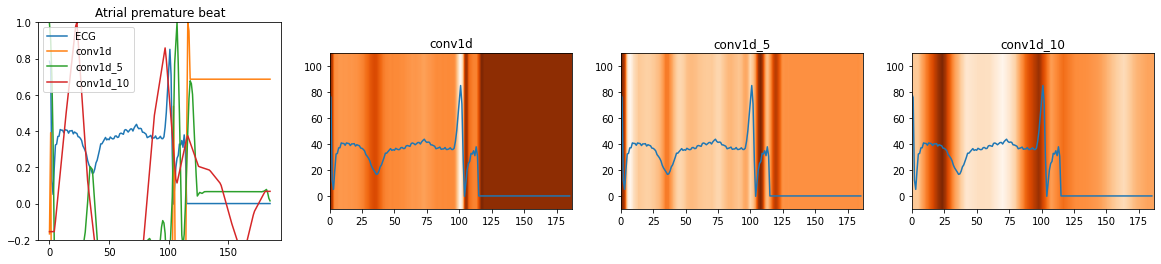

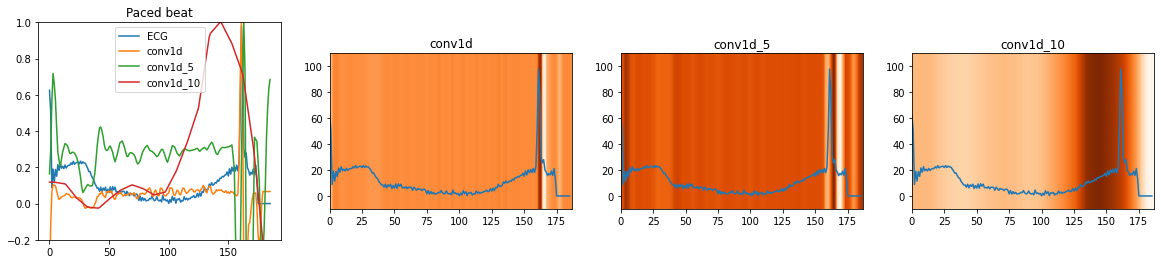

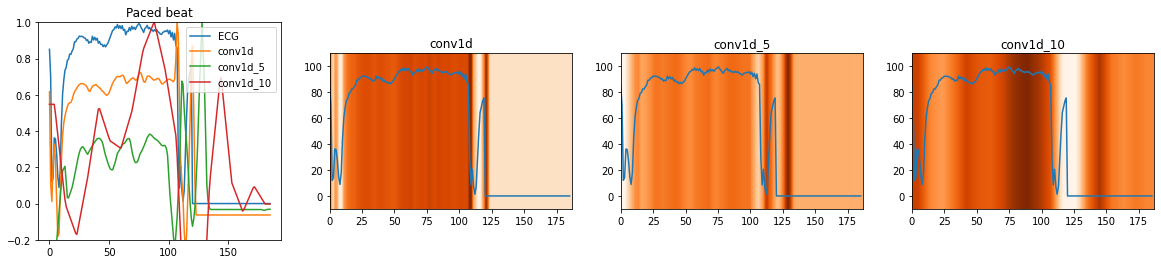

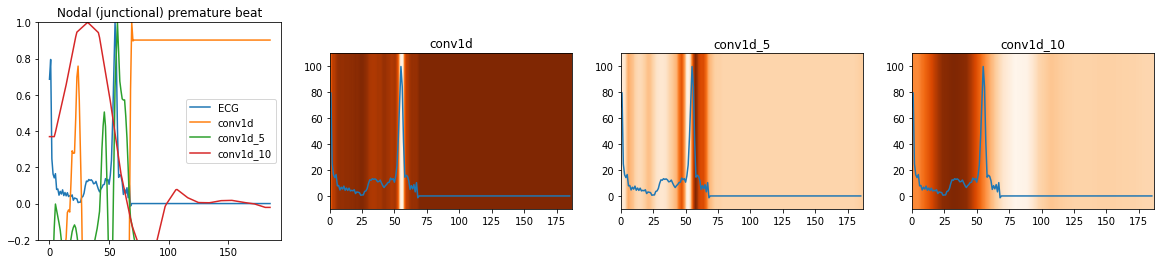

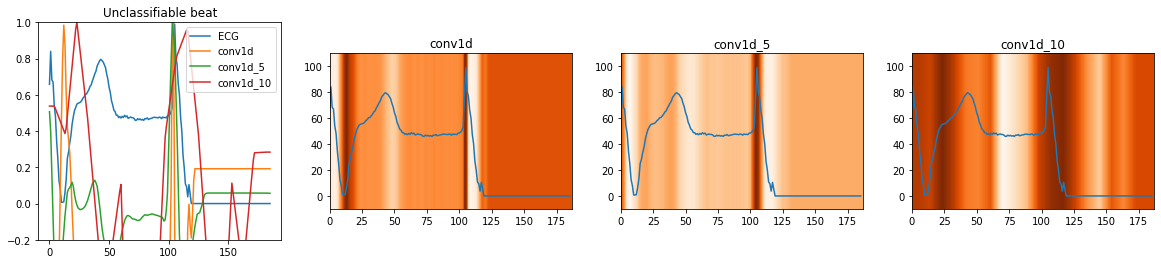

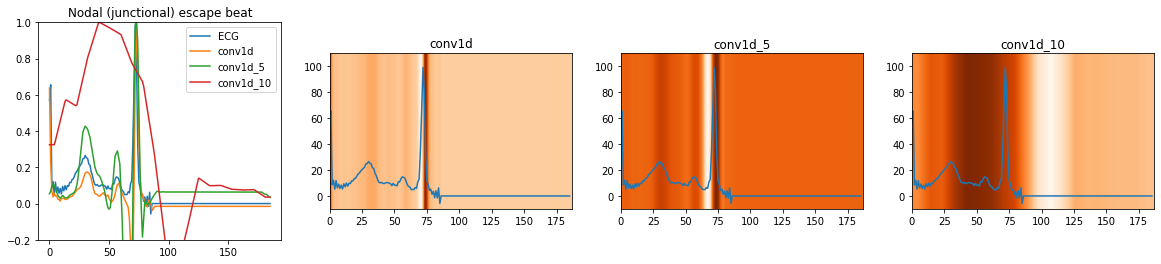

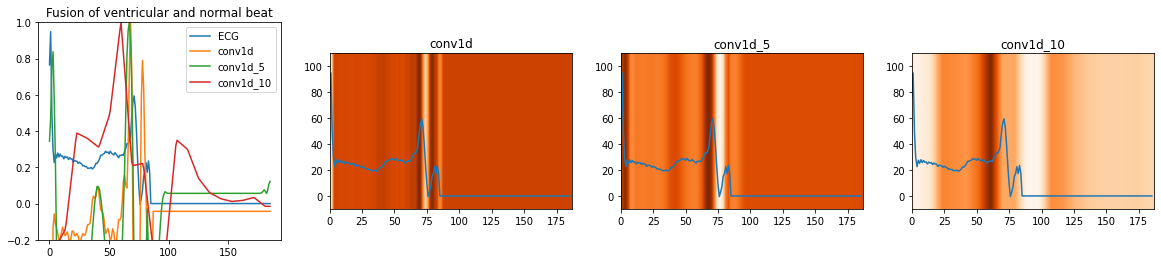

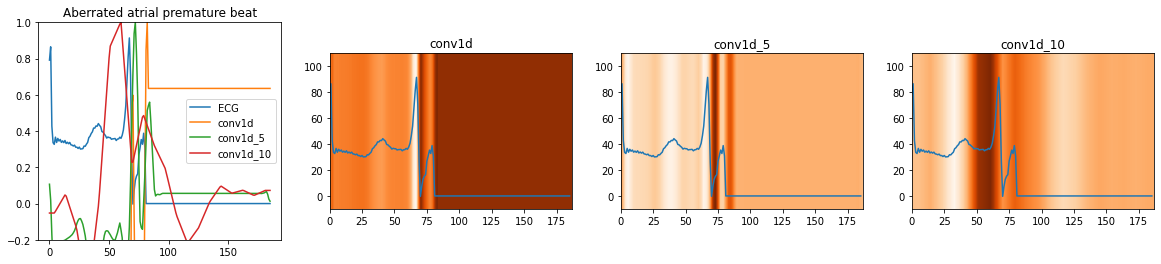

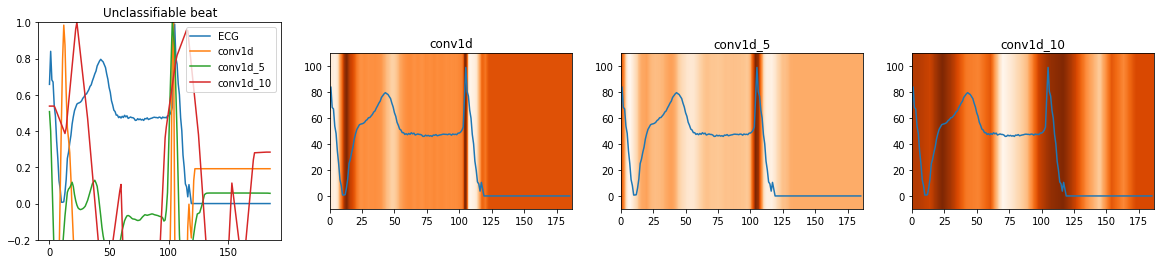

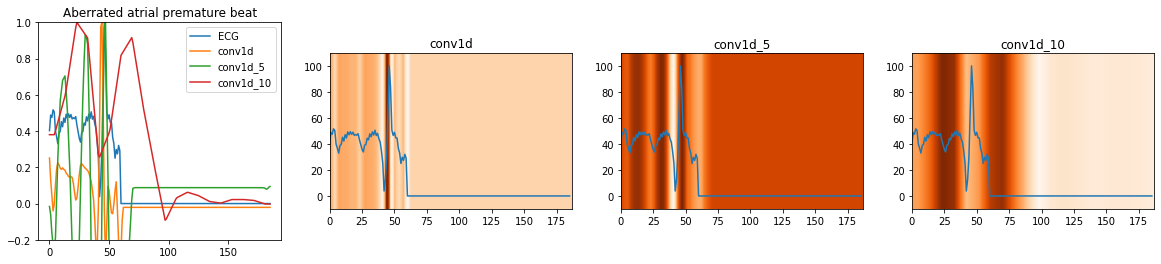

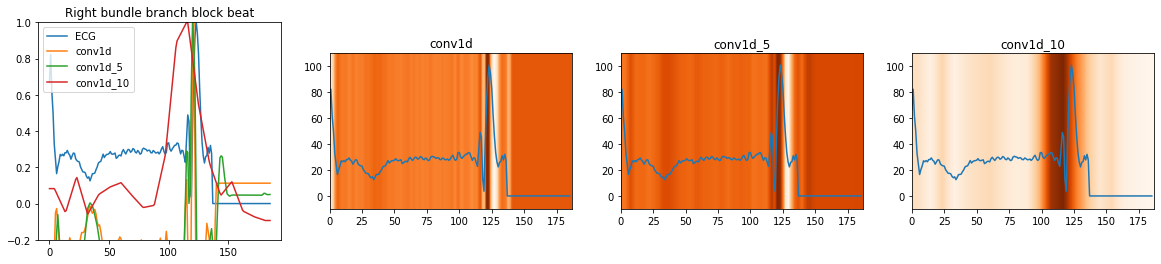

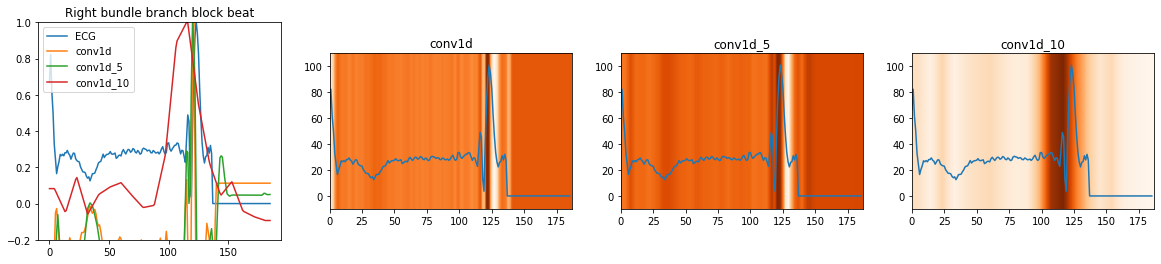

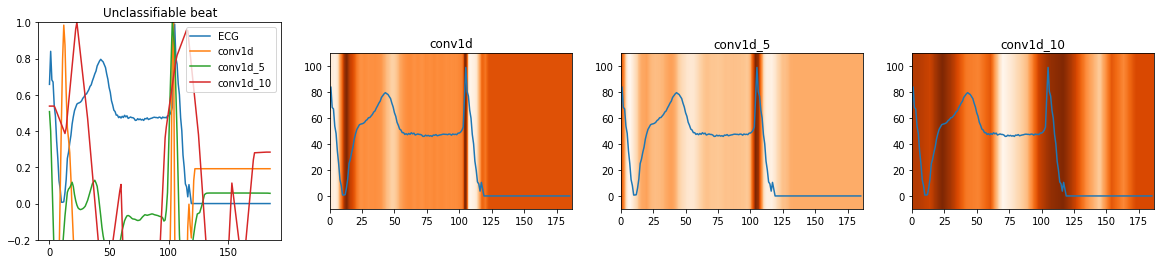

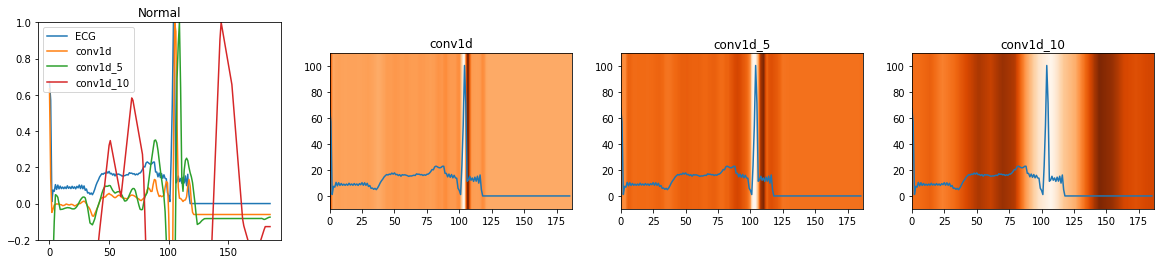

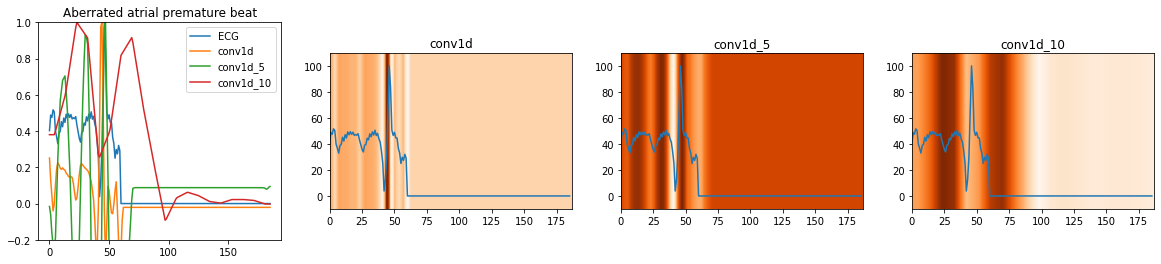

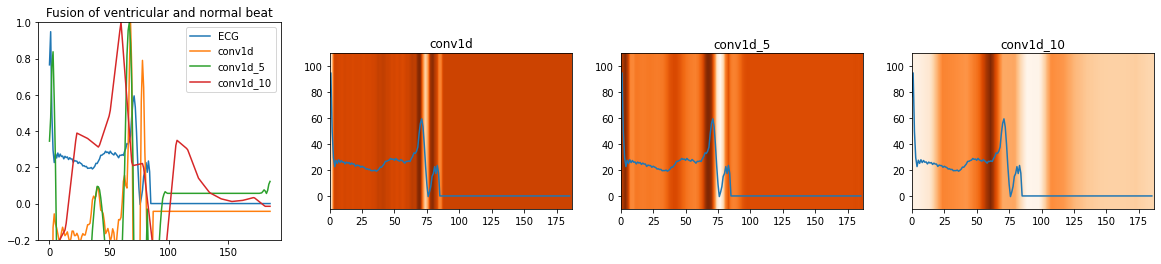

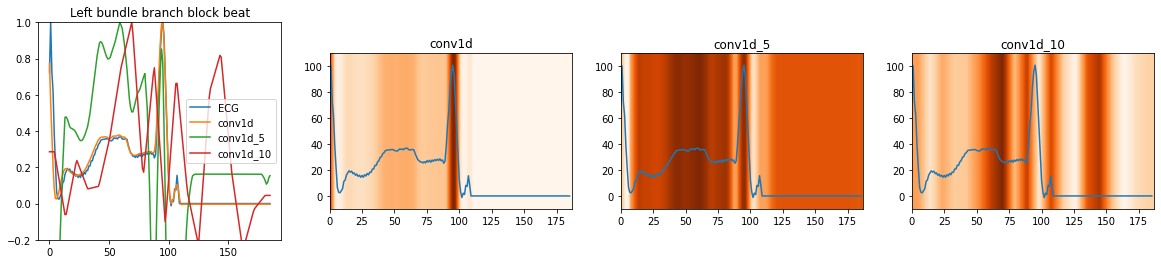

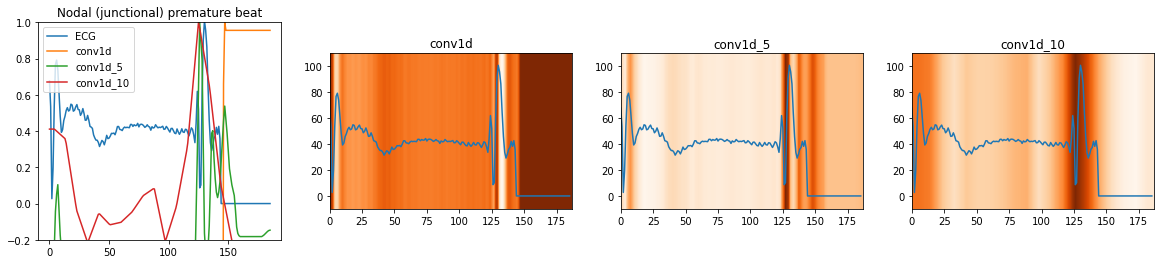

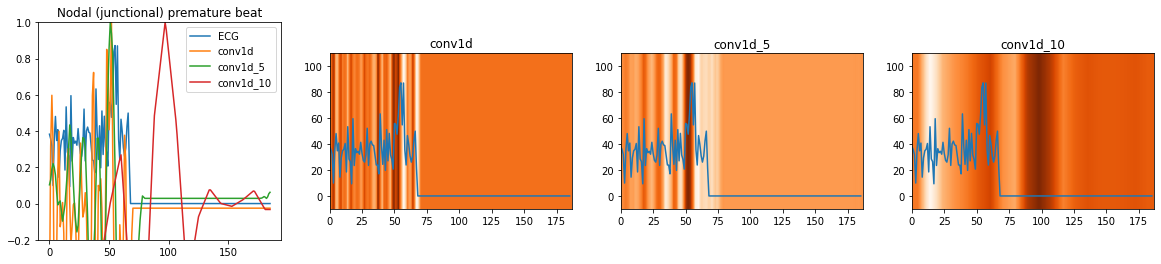

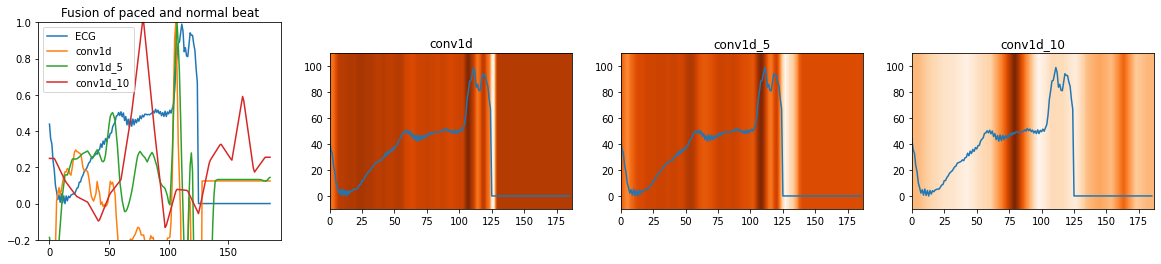

In [51]:
for i in range(20):
    Collect_heatmap = list()
    index = np.random.randint(0,len(X_display))
    name_list = ["conv1d",  "conv1d_5", "conv1d_10"]
    for name in name_list:
        heatmap, pred_class = gradcam(model, X_display, index, name)
        Collect_heatmap.append(heatmap)
    data = X_display[index]
    if int(y_display[index][0]==1): 
      title = "Normal"
    elif int(y_display[index][1]==1):
      title = "Left bundle branch block beat"
    elif int(y_display[index][2]==1):
      title = "Right bundle branch block beat"
    elif int(y_display[index][3]==1):
      title = "Atrial premature beat"
    elif int(y_display[index][4]==1):
      title = "Aberrated atrial premature beat"
    elif int(y_display[index][5]==1):
      title = "Nodal (junctional) premature beat"
   
    elif int(y_display[index][6]==1):
      title = "Premature ventricular contraction"
    elif int(y_display[index][7]==1):
      title = "Fusion of ventricular and normal beat"
 
    elif int(y_display[index][8]==1):
      title = "Nodal (junctional) escape beat"
    elif int(y_display[index][9]==1):
      title = "Ventricular escape beat"
    elif int(y_display[index][10]==1):
      title = "Paced beat"
    elif int(y_display[index][11]==1):
      title = "Fusion of paced and normal beat"
    elif int(y_display[index][12]==1):
      title = "Unclassifiable beat"
   
    heatmap_3x()